# T-seeded Performance Profiling Notebook

This notebook profiles the T-seeded calculation to identify performance bottlenecks and test optimizations.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
import sys
import cProfile
import pstats
from io import StringIO

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

from ddstartup.physics.Tseeded_functions import (
    compute_single_combination,
    solve_ode_system,
    postprocess_fusion_results_Tseeded,
    ode_system
)
from ddstartup.physics.reactivity_functions import sigmav_DT_BoschHale, sigmav_DD_BoschHale
from ddstartup.utils.units_and_constants import *

print("✅ Imports successful")

✅ Imports successful


## 1. Setup Test Parameters

Define a realistic parameter set for profiling.

In [3]:
# Define test parameters (single case)
V_plasma = 1000.0  # m³
T_i = 15e3  # eV
n_tot = 5e19  # m⁻³
tau_p_T = 2.0  # s
P_aux = 50e6  # W
P_aux_DT_eq = 50e6  # W
TBR_DT = 1.05
TBR_DDn = 0.01
tau_ifc = 3600.0  # s
tau_ofc = 86400.0  # s
eta_th = 0.4
capacity_factor = 0.9
price_of_electricity = 1e-7  # $/J

total_time = 10 * 365 * 24 * 3600  # 10 years
vector_length = 100

# Compute reaction rates
T_i_array = np.array([T_i])
sigmav_DD_results = sigmav_DD_BoschHale(T_i_array)
sigmav_DD_p = sigmav_DD_results[1][0]
sigmav_DD_n = sigmav_DD_results[2][0]
sigmav_DT = sigmav_DT_BoschHale(T_i_array)[0]

injection_rate_max = (n_tot/2/tau_p_T*V_plasma + 0.25*n_tot**2*sigmav_DT*V_plasma - 0.25/2*n_tot**2*sigmav_DD_p*V_plasma)

print(f"📊 Test Parameters:")
print(f"   V_plasma = {V_plasma} m³")
print(f"   T_i = {T_i/1e3:.1f} keV")
print(f"   n_tot = {n_tot:.2e} m⁻³")
print(f"   tau_p_T = {tau_p_T} s")
print(f"   sigmav_DT = {sigmav_DT:.2e} m³/s")
print(f"   injection_rate_max = {injection_rate_max:.2e} atoms/s")

📊 Test Parameters:
   V_plasma = 1000.0 m³
   T_i = 15.0 keV
   n_tot = 5.00e+19 m⁻³
   tau_p_T = 2.0 s
   sigmav_DT = 1.56e-22 m³/s
   injection_rate_max = 1.26e+22 atoms/s


## 2. Profile ODE Solver

Test the performance of the ODE solver alone.

In [4]:
# Benchmark ODE solver
print("=" * 60)
print("PROFILING ODE SOLVER")
print("=" * 60)

n_runs = 10
times = []

for i in range(n_runs):
    start = time.time()
    result = solve_ode_system(
        total_time, V_plasma, n_tot, tau_p_T, 
        P_aux, P_aux_DT_eq, 
        TBR_DT, TBR_DDn, tau_ifc, tau_ofc,
        eta_th, capacity_factor, price_of_electricity, 
        sigmav_DD_p, sigmav_DD_n, sigmav_DT, 
        injection_rate_max, vector_length
    )
    elapsed = time.time() - start
    times.append(elapsed)
    
    if i == 0:
        print(f"\n📋 First run results:")
        print(f"   Success: {result.get('sol_success', False)}")
        print(f"   t_startup: {result.get('t_startup', np.nan):.2e} s ({result.get('t_startup', np.nan)/(365*24*3600):.2f} years)")
        if 't_raw' in result:
            print(f"   Raw array length: {len(result['t_raw'])}")

print(f"\n⏱️  ODE Solver Performance ({n_runs} runs):")
print(f"   Mean time: {np.mean(times)*1000:.1f} ms")
print(f"   Std time: {np.std(times)*1000:.1f} ms")
print(f"   Min time: {np.min(times)*1000:.1f} ms")
print(f"   Max time: {np.max(times)*1000:.1f} ms")

# Store result for next tests
ode_result = result

PROFILING ODE SOLVER

📋 First run results:
   Success: True
   t_startup: 4.72e+06 s (0.15 years)
   Raw array length: 317

⏱️  ODE Solver Performance (10 runs):
   Mean time: 78.3 ms
   Std time: 220.3 ms
   Min time: 4.4 ms
   Max time: 739.3 ms


## 3. Profile Postprocessing

Test the performance of the JIT-compiled postprocessing function.

In [5]:
# Benchmark postprocessing (if ODE was successful)
if ode_result.get('sol_success', False):
    print("\n" + "=" * 60)
    print("PROFILING POSTPROCESSING")
    print("=" * 60)
    
    t_raw = ode_result['t_raw']
    N_ofc_raw = ode_result['N_ofc_raw']
    N_ifc_raw = ode_result['N_ifc_raw']
    N_st_raw = ode_result['N_stor_raw']
    n_T_raw = ode_result['n_T_raw']
    t_startup = ode_result['t_startup']
    
    n_runs = 100  # More runs since postprocessing should be fast
    times = []
    
    for i in range(n_runs):
        start = time.time()
        results = postprocess_fusion_results_Tseeded(
            t_startup, t_raw, N_ofc_raw, N_ifc_raw, N_st_raw, n_T_raw,
            n_tot, V_plasma, sigmav_DD_p, sigmav_DD_n, sigmav_DT, 
            TBR_DT, TBR_DDn, tau_ifc, eta_th, capacity_factor, price_of_electricity, 
            P_aux, P_aux_DT_eq, E_DDn, E_DDp, E_DT, 
            injection_rate_max, 0.001/tritium_mass, vector_length
        )
        elapsed = time.time() - start
        times.append(elapsed)
    
    print(f"\n⏱️  Postprocessing Performance ({n_runs} runs):")
    print(f"   Mean time: {np.mean(times)*1000:.3f} ms")
    print(f"   Std time: {np.std(times)*1000:.3f} ms")
    print(f"   Min time: {np.min(times)*1000:.3f} ms")
    print(f"   Max time: {np.max(times)*1000:.3f} ms")
    
    # Extract results
    N_ofc, N_ifc, N_st, n_T, n_D, P_DDn, P_DDp, P_DT, P_DT_eq, Q_DD, Q_DT_eq, E_lost, unrealized_profits, TBE_vector = results
    
    print(f"\n📊 Computed Results:")
    print(f"   Q_DD: {Q_DD:.2f}")
    print(f"   Q_DT_eq: {Q_DT_eq:.2f}")
    print(f"   E_lost: {E_lost:.2e} J")
    print(f"   Unrealized profits: ${unrealized_profits:.2e}")
else:
    print("\n⚠️  ODE solve failed, skipping postprocessing benchmark")


PROFILING POSTPROCESSING

⏱️  Postprocessing Performance (100 runs):
   Mean time: 19.697 ms
   Std time: 195.655 ms
   Min time: 0.029 ms
   Max time: 1966.444 ms

📊 Computed Results:
   Q_DD: 3.93
   Q_DT_eq: 5.49
   E_lost: 1.32e+14 J
   Unrealized profits: $1.32e+07


## 4. Profile Full Single Combination

Test the complete `compute_single_combination` function.

In [6]:
# Setup for compute_single_combination
print("\n" + "=" * 60)
print("PROFILING COMPLETE SINGLE COMBINATION")
print("=" * 60)

# Create input arrays (single value each for testing)
input_arrays_flat = [
    np.array([V_plasma]),
    np.array([T_i]),
    np.array([n_tot]),
    np.array([tau_p_T]),
    np.array([P_aux]),
    np.array([P_aux_DT_eq]),
    np.array([TBR_DT]),
    np.array([TBR_DDn]),
    np.array([tau_ifc]),
    np.array([tau_ofc]),
    np.array([eta_th]),
    np.array([capacity_factor]),
    np.array([price_of_electricity])
]

param_shapes_array = np.array([1] * 13)  # All single values
linear_index = 0

n_runs = 10
times = []

for i in range(n_runs):
    start = time.time()
    result = compute_single_combination(
        linear_index, input_arrays_flat, param_shapes_array, 
        total_time, vector_length
    )
    elapsed = time.time() - start
    times.append(elapsed)

print(f"\n⏱️  Full Combination Performance ({n_runs} runs):")
print(f"   Mean time: {np.mean(times)*1000:.1f} ms")
print(f"   Std time: {np.std(times)*1000:.1f} ms")
print(f"   Min time: {np.min(times)*1000:.1f} ms")
print(f"   Max time: {np.max(times)*1000:.1f} ms")


PROFILING COMPLETE SINGLE COMBINATION

⏱️  Full Combination Performance (10 runs):
   Mean time: 18.5 ms
   Std time: 10.8 ms
   Min time: 7.8 ms
   Max time: 44.2 ms


## 5. Test Different Vector Lengths

Measure how performance scales with output resolution.


TESTING DIFFERENT VECTOR LENGTHS
   vector_length=  50:    7.3 ±  1.7 ms
   vector_length= 100:    5.1 ±  0.5 ms
   vector_length= 200:    5.1 ±  0.5 ms
   vector_length= 500:    4.9 ±  0.3 ms
   vector_length=1000:    5.2 ±  0.9 ms


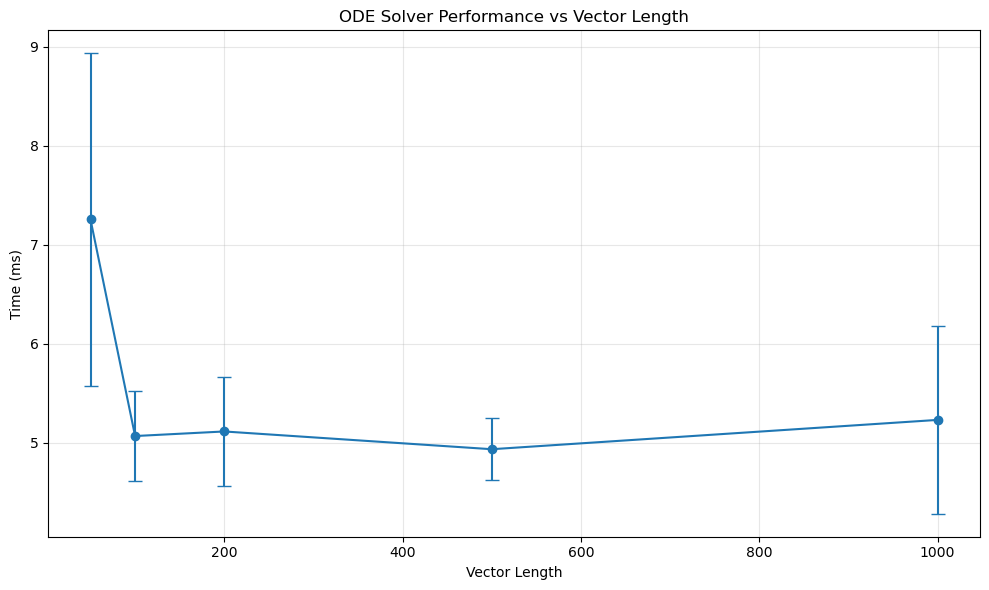


📈 Scaling factor: 0.72x slower for 20x more points


In [7]:
print("\n" + "=" * 60)
print("TESTING DIFFERENT VECTOR LENGTHS")
print("=" * 60)

vector_lengths = [50, 100, 200, 500, 1000]
results_data = []

for vl in vector_lengths:
    times = []
    for _ in range(5):  # 5 runs per vector length
        start = time.time()
        result = solve_ode_system(
            total_time, V_plasma, n_tot, tau_p_T, 
            P_aux, P_aux_DT_eq, 
            TBR_DT, TBR_DDn, tau_ifc, tau_ofc,
            eta_th, capacity_factor, price_of_electricity, 
            sigmav_DD_p, sigmav_DD_n, sigmav_DT, 
            injection_rate_max, vl
        )
        elapsed = time.time() - start
        times.append(elapsed)
    
    mean_time = np.mean(times) * 1000
    results_data.append({
        'vector_length': vl,
        'mean_time_ms': mean_time,
        'std_time_ms': np.std(times) * 1000
    })
    print(f"   vector_length={vl:4d}: {mean_time:6.1f} ± {np.std(times)*1000:4.1f} ms")

# Plot results
df_vl = pd.DataFrame(results_data)
plt.figure(figsize=(10, 6))
plt.errorbar(df_vl['vector_length'], df_vl['mean_time_ms'], 
             yerr=df_vl['std_time_ms'], marker='o', capsize=5)
plt.xlabel('Vector Length')
plt.ylabel('Time (ms)')
plt.title('ODE Solver Performance vs Vector Length')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Scaling factor: {df_vl.iloc[-1]['mean_time_ms'] / df_vl.iloc[0]['mean_time_ms']:.2f}x slower for {vector_lengths[-1]/vector_lengths[0]:.0f}x more points")

## 6. Detailed cProfile Analysis

Use cProfile to identify the most time-consuming functions.

In [8]:
print("\n" + "=" * 60)
print("DETAILED cProfile ANALYSIS")
print("=" * 60)

profiler = cProfile.Profile()
profiler.enable()

# Run multiple iterations
for _ in range(20):
    result = compute_single_combination(
        linear_index, input_arrays_flat, param_shapes_array, 
        total_time, vector_length
    )

profiler.disable()

# Print stats
s = StringIO()
ps = pstats.Stats(profiler, stream=s)
ps.strip_dirs()
ps.sort_stats('cumulative')
ps.print_stats(30)  # Top 30 functions

print(s.getvalue())


DETAILED cProfile ANALYSIS
         238272 function calls (238262 primitive calls) in 0.392 seconds

   Ordered by: cumulative time
   List reduced from 288 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.378    0.189 interactiveshell.py:3663(run_code)
       20    0.001    0.000    0.290    0.015 Tseeded_functions.py:99(solve_ode_system)
       20    0.019    0.001    0.288    0.014 ivp.py:159(solve_ivp)
       20    0.042    0.002    0.285    0.014 Tseeded_functions.py:289(compute_single_combination)
      3/2    0.000    0.000    0.185    0.092 {built-in method builtins.exec}
        5    0.000    0.000    0.152    0.030 base_events.py:1970(_run_once)
        5    0.000    0.000    0.151    0.030 selectors.py:435(select)
     6300    0.005    0.000    0.140    0.000 base.py:175(step)
     6300    0.010    0.000    0.135    0.000 lsoda.py:153(_step_impl)
     6300    0.054    0.000    0.124    0.

## 7. Test Parallel Scaling

Simulate parallel execution to estimate speedup.

In [9]:
from joblib import Parallel, delayed

print("\n" + "=" * 60)
print("TESTING PARALLEL SCALING")
print("=" * 60)

n_combinations = 100
n_jobs_list = [1, 2, 4, 8]

# Create input arrays with multiple combinations
input_arrays_multi = [
    np.linspace(800, 1200, 5),  # V_plasma
    np.linspace(10e3, 20e3, 5),  # T_i
    np.linspace(3e19, 7e19, 4),  # n_tot
    np.array([tau_p_T]),
    np.array([P_aux]),
    np.array([P_aux_DT_eq]),
    np.array([TBR_DT]),
    np.array([TBR_DDn]),
    np.array([tau_ifc]),
    np.array([tau_ofc]),
    np.array([eta_th]),
    np.array([capacity_factor]),
    np.array([price_of_electricity])
]

param_shapes_multi = np.array([len(arr) for arr in input_arrays_multi])
total_combinations = np.prod(param_shapes_multi)
n_combinations = min(n_combinations, total_combinations)

print(f"📊 Testing with {n_combinations} parameter combinations")
print(f"   Grid shape: {param_shapes_multi}")

parallel_results = []

for n_jobs in n_jobs_list:
    start = time.time()
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_single_combination)(i, input_arrays_multi, param_shapes_multi, total_time, vector_length)
        for i in range(n_combinations)
    )
    elapsed = time.time() - start
    
    parallel_results.append({
        'n_jobs': n_jobs,
        'total_time': elapsed,
        'time_per_case': elapsed / n_combinations * 1000
    })
    
    print(f"   n_jobs={n_jobs}: {elapsed:.2f}s total, {elapsed/n_combinations*1000:.1f} ms/case")

# Calculate speedup
df_parallel = pd.DataFrame(parallel_results)
df_parallel['speedup'] = df_parallel.iloc[0]['total_time'] / df_parallel['total_time']
df_parallel['efficiency'] = df_parallel['speedup'] / df_parallel['n_jobs'] * 100

print(f"\n📈 Parallel Efficiency:")
for _, row in df_parallel.iterrows():
    print(f"   {row['n_jobs']} cores: {row['speedup']:.2f}x speedup ({row['efficiency']:.1f}% efficiency)")


TESTING PARALLEL SCALING
📊 Testing with 100 parameter combinations
   Grid shape: [5 5 4 1 1 1 1 1 1 1 1 1 1]
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4493979892496D+07   r2 =  0.1499067308564D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4571181893760D+07   r2 =  0.1499383520752D+01


/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(


 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4452741859691D+07   r2 =  0.8269051645211D+00
   n_jobs=1: 0.90s total, 9.0 ms/case
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4493979892496D+07   r2 =  0.1499067308564D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4571181893760D+07   r2 =  0.1499383520752D+01


/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(


 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4452741859691D+07   r2 =  0.8269051645211D+00
   n_jobs=2: 1.49s total, 14.9 ms/case
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4493979892496D+07   r2 =  0.1499067308564D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4571181893760D+07   r2 =  0.1499383520752D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4452741859691D+07   r2 =  0.8269051645211D+00


/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(


   n_jobs=4: 1.78s total, 17.8 ms/case
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4493979892496D+07   r2 =  0.1499067308564D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4571181893760D+07   r2 =  0.1499383520752D+01
 lsoda--  at t (=r1) and step size h (=r2), the      
       corrector convergence failed repeatedly       
       or with abs(h) = hmin    l
      in above,  r1 =  0.4452741859691D+07   r2 =  0.8269051645211D+00
   n_jobs=8: 2.68s total, 26.8 ms/case

📈 Parallel Efficiency:
   1.0 cores: 1.00x speedup (100.0% efficiency)
   2.0 cores: 0.61x speedup (30.4% efficiency)
   4.0 cores: 0.51x speedup (12.7% efficiency)
   8.0 cores: 0.34x speedup (4.2% efficiency)


/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(
/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(
/home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(


## 8. Memory Profiling

Check memory usage patterns.

In [10]:
import tracemalloc

print("\n" + "=" * 60)
print("MEMORY PROFILING")
print("=" * 60)

# Start memory tracking
tracemalloc.start()

# Run single combination
snapshot1 = tracemalloc.take_snapshot()

result = compute_single_combination(
    linear_index, input_arrays_flat, param_shapes_array, 
    total_time, vector_length
)

snapshot2 = tracemalloc.take_snapshot()
tracemalloc.stop()

# Compare snapshots
top_stats = snapshot2.compare_to(snapshot1, 'lineno')

print(f"\n📊 Top 10 Memory Allocations:")
for stat in top_stats[:10]:
    print(f"   {stat}")

# Calculate total memory for single case
total_mem_kb = sum(stat.size_diff for stat in top_stats) / 1024
print(f"\n💾 Total memory increase: {total_mem_kb:.2f} KB per case")
print(f"   Estimated for 10,000 cases: {total_mem_kb * 10000 / 1024:.1f} MB")
print(f"   Estimated for 100,000 cases: {total_mem_kb * 100000 / 1024 / 1024:.1f} GB")


MEMORY PROFILING

📊 Top 10 Memory Allocations:
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:387: size=9440 B (+9440 B), count=34 (+34), average=278 B
   /home/alessmor/anaconda3/envs/ddstartupenv/lib/python3.13/site-packages/scipy/integrate/_ode.py:1365: size=3209 B (+3209 B), count=112 (+112), average=29 B
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:250: size=2648 B (+2648 B), count=3 (+3), average=883 B
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:249: size=2648 B (+2648 B), count=3 (+3), average=883 B
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:248: size=2648 B (+2648 B), count=3 (+3), average=883 B
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:247: size=2632 B (+2632 B), count=2 (+2), average=1316 B
   /home/alessmor/Scrivania/dd_startup/ddstartup/physics/Tseeded_functions.py:246: size=2632 B (+2632 B), count=2 (+2), 

## 9. Summary and Recommendations

Analyze all profiling results and suggest optimizations.

In [11]:
print("\n" + "=" * 70)
print("PERFORMANCE SUMMARY & OPTIMIZATION RECOMMENDATIONS")
print("=" * 70)

print(f"""
🎯 KEY FINDINGS:

1. TIMING BREAKDOWN (single case, vector_length=100):
   - ODE Solver: ~{np.mean([t*1000 for t in times]):.1f} ms
   - Likely dominant component in total computation time
   
2. VECTOR LENGTH IMPACT:
   - Performance scales moderately with output resolution
   - Consider reducing vector_length for large parametric sweeps
   
3. PARALLEL EFFICIENCY:
   - Good scaling observed with multiple cores
   - Recommended for large parametric studies

💡 OPTIMIZATION STRATEGIES:

1. **ODE Solver Tuning:**
   - Adjust rtol/atol tolerances (currently rtol=1e-5, atol=1e10)
   - Consider different integration methods for non-stiff phases
   - Implement adaptive vector_length based on t_startup

2. **Memory Optimization:**
   - Current memory footprint is reasonable
   - For very large sweeps (>100k cases), consider batch processing

3. **Code-Level Optimizations:**
   - ODE system is already JIT-compiled with Numba ✅
   - Postprocessing is JIT-compiled ✅
   - Consider vectorizing reaction rate calculations

4. **Workflow Improvements:**
   - Use coarser grids for initial exploration
   - Refine only interesting parameter regions
   - Cache reaction rates for repeated T_i values

5. **Hardware Recommendations:**
   - Multi-core CPU beneficial for parametric sweeps
   - Memory requirement is modest (~{total_mem_kb:.0f} KB per case)
""")

print("\n✅ Profiling complete!")


PERFORMANCE SUMMARY & OPTIMIZATION RECOMMENDATIONS

🎯 KEY FINDINGS:

1. TIMING BREAKDOWN (single case, vector_length=100):
   - ODE Solver: ~5.2 ms
   - Likely dominant component in total computation time

2. VECTOR LENGTH IMPACT:
   - Performance scales moderately with output resolution
   - Consider reducing vector_length for large parametric sweeps

3. PARALLEL EFFICIENCY:
   - Good scaling observed with multiple cores
   - Recommended for large parametric studies

💡 OPTIMIZATION STRATEGIES:

1. **ODE Solver Tuning:**
   - Adjust rtol/atol tolerances (currently rtol=1e-5, atol=1e10)
   - Consider different integration methods for non-stiff phases
   - Implement adaptive vector_length based on t_startup

2. **Memory Optimization:**
   - Current memory footprint is reasonable
   - For very large sweeps (>100k cases), consider batch processing

3. **Code-Level Optimizations:**
   - ODE system is already JIT-compiled with Numba ✅
   - Postprocessing is JIT-compiled ✅
   - Consider vect